# 05 — Hierarchical Risk Parity (HRP) Portfolio

**Purpose:** Translate daily alpha signals → optimal portfolio weights via HRP,
conditioned on P(Success) from the meta-model and the current market regime.

**Why HRP over MPT:**
- MPT requires inverting the covariance matrix (numerically unstable with many assets)
- MPT assumes normal return distributions (empirically violated)
- HRP is robust, data-efficient, and performs better out-of-sample

**HRP Pipeline:**
1. Select top-N stocks by ensemble signal (filtered by P(Success) > threshold)
2. Build distance matrix from correlation matrix: $D = \sqrt{0.5(1 - \rho)}$
3. Hierarchical clustering (Ward's method)
4. Quasi-diagonalization of covariance matrix
5. Recursive bisection: allocate inversely proportional to cluster variance
6. Kelly sizing: scale weights by P(Success)
7. Apply risk constraints (max position, sector concentration)

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import warnings
import json
import pickle
from typing import Dict, List, Tuple, Optional

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────────────────────────
WD = Path('.')

# ── Parameters ────────────────────────────────────────────────────────────────
TOP_N             = 30       # candidates from alpha model per period
PSUCCESS_MIN      = 0.52     # minimum P(Success) to include in portfolio
COV_LOOKBACK      = 63       # trading days for covariance estimation
MAX_WEIGHT        = 0.15     # max weight per stock (15%)
MIN_WEIGHT        = 0.001    # min weight (floor at 0.1%)
KELLY_FRACTION    = 0.5      # fractional Kelly multiplier (half-Kelly safety)
REBAL_DAYS        = 5        # rebalance every N trading days
TC_BPS            = 5        # one-way transaction cost (basis points)

# Regime-conditional leverage (scale position size by regime)
REGIME_LEVERAGE   = {0: 1.0, 1: 0.7, 2: 0.4}  # Bull=1x, Transition=0.7x, Bear=0.4x

print('✓ Imports loaded')

✓ Imports loaded


## 1 — Load All Upstream Outputs

In [2]:
# Feature panel (daily returns)
panel = pd.read_parquet(WD / 'features_panel.parquet')
panel['date'] = pd.to_datetime(panel['date'])

# OOS predictions from alpha models
oos_preds = pd.read_parquet(WD / 'oos_predictions.parquet')
oos_preds['date'] = pd.to_datetime(oos_preds['date'])

# P(Success) from meta-model
p_success_df = pd.read_parquet(WD / 'p_success.parquet')
p_success_df['date'] = pd.to_datetime(p_success_df['date'])

# Regime states
regime_df = pd.read_parquet(WD / 'regime_states.parquet')
regime_df['date'] = pd.to_datetime(regime_df['date'])

# Load metadata
with open(WD / 'meta_model_meta.json', 'r') as f:
    meta_meta = json.load(f)

print(f'Panel: {len(panel):,} rows')
print(f'OOS predictions: {len(oos_preds):,} rows')
print(f'P(Success): {len(p_success_df):,} rows')
print(f'Regime dates: {len(regime_df):,}')

Panel: 1,512,735 rows
OOS predictions: 606,878 rows
P(Success): 606,878 rows
Regime dates: 3,117


In [3]:
# ── Merge all signals ─────────────────────────────────────────────────────────
# Start from alpha predictions (the backbone of our universe)
signals = oos_preds[['date', 'ticker', 'pred_ensemble', 'target_cs_rank', 'fwd_ret_5d']].copy()

# Merge P(Success)
signals = signals.merge(
    p_success_df[['date', 'ticker', 'p_success', 'vol_sigma']],
    on=['date', 'ticker'],
    how='left'
)

# Merge regime state
signals = signals.merge(
    regime_df[['date', 'regime', 'p_bull', 'p_bear']],
    on='date',
    how='left'
)

# Merge actual log_ret from panel (needed for covariance estimation)
signals = signals.merge(
    panel[['date', 'ticker', 'log_ret']],
    on=['date', 'ticker'],
    how='left'
)

signals = signals.dropna(subset=['pred_ensemble', 'p_success', 'regime'])
signals = signals.sort_values(['date', 'ticker']).reset_index(drop=True)

print(f'Combined signals: {len(signals):,} rows')
print(f'Date range: {signals["date"].min().date()} → {signals["date"].max().date()}')

Combined signals: 606,878 rows
Date range: 2014-01-22 → 2019-01-23


## 2 — HRP Core Algorithm

In [4]:
# ── HRP Implementation (Lopez de Prado, 2016) ────────────────────────────────

def corr_to_distance(corr: np.ndarray) -> np.ndarray:
    """Convert correlation matrix to distance matrix: D = sqrt(0.5*(1 - corr))."""
    dist = np.sqrt(0.5 * (1.0 - corr))
    np.fill_diagonal(dist, 0)
    return dist


def get_quasi_diagonal(link: np.ndarray) -> List[int]:
    """Sort clustered items by quasi-diagonalization order."""
    link   = link.astype(int)
    sortIx = pd.Series([link[-1, 0], link[-1, 1]])
    numItems = link[-1, 3]  # number of original items

    while sortIx.max() >= numItems:
        sortIx.index = range(0, sortIx.shape[0] * 2, 2)  # make space
        df0 = sortIx[sortIx >= numItems]  # find clusters
        i   = df0.index
        j   = df0.values - numItems
        sortIx[i] = link[j, 0]  # item 1
        df0        = pd.Series(link[j, 1], index=i + 1)
        sortIx     = pd.concat([sortIx, df0])
        sortIx     = sortIx.sort_index()
        sortIx.index = range(sortIx.shape[0])

    return sortIx.tolist()


def get_recursive_bisection(cov: pd.DataFrame, sort_ix: List[int]) -> pd.Series:
    """Compute HRP weights via recursive bisection."""
    w = pd.Series(1.0, index=sort_ix)
    cluster_items = [sort_ix]

    while len(cluster_items) > 0:
        # Bisect each cluster
        new_clusters = []
        for cluster in cluster_items:
            if len(cluster) > 1:
                half   = len(cluster) // 2
                cLeft  = cluster[:half]
                cRight = cluster[half:]

                # Cluster variance = w^T × Σ × w (equal-weight within sub-cluster)
                def cluster_variance(items):
                    sub_cov = cov.iloc[items, :][:, items]
                    w_sub   = pd.Series(1.0 / len(items), index=items)
                    return float(w_sub @ sub_cov.values @ w_sub)

                var_L = cluster_variance(cLeft)
                var_R = cluster_variance(cRight)

                # Allocate inversely proportional to variance
                alpha = 1.0 - var_L / (var_L + var_R + 1e-12)

                w[cLeft]  *= alpha
                w[cRight] *= (1.0 - alpha)

                new_clusters.extend([cLeft, cRight])

        cluster_items = new_clusters

    return w


def hrp_weights(
    returns_df:  pd.DataFrame,
    method:      str = 'ward'
) -> pd.Series:
    """
    Compute HRP weights from a returns DataFrame (rows=dates, cols=tickers).
    Returns a pd.Series of weights (sum = 1).
    """
    # Correlation & covariance
    corr   = returns_df.corr().fillna(0).values
    cov_pd = returns_df.cov()
    tickers = returns_df.columns.tolist()

    # Distance matrix → hierarchical clustering
    dist  = corr_to_distance(corr)
    dist_condensed = squareform(dist, checks=False)
    link  = linkage(dist_condensed, method=method)

    # Quasi-diagonalization
    sort_ix = get_quasi_diagonal(link)
    sort_ix = [int(i) for i in sort_ix if int(i) < len(tickers)]

    # Recursive bisection
    weights = get_recursive_bisection(cov_pd, sort_ix)

    # Reindex to original ticker order
    w = pd.Series(0.0, index=range(len(tickers)))
    w.update(weights)
    w.index = tickers
    w = w / w.sum()  # normalize
    return w


print('HRP functions defined ✓')

HRP functions defined ✓


In [5]:
def apply_kelly_sizing(
    hrp_w:      pd.Series,
    p_success:  Dict[str, float],
    kelly_frac: float = KELLY_FRACTION
) -> pd.Series:
    """
    Scale HRP weights by fractional Kelly bet size.
    Kelly: f* = (p*b - q) / b ≈ 2p - 1 for b≈1 (symmetric payoff)
    """
    kelly = pd.Series({
        ticker: max(0.0, 2 * p_success.get(ticker, 0.5) - 1) * kelly_frac
        for ticker in hrp_w.index
    })
    scaled_w = hrp_w * kelly
    total = scaled_w.sum()
    return scaled_w / total if total > 0 else hrp_w


def apply_risk_constraints(
    weights:  pd.Series,
    max_w:    float = MAX_WEIGHT,
    min_w:    float = MIN_WEIGHT
) -> pd.Series:
    """Iterative clipping to enforce max/min position size constraints."""
    w = weights.copy()
    for _ in range(20):  # iterate until convergence
        w = w.clip(lower=0)    # no short positions in long-only portfolio
        excess = w[w > max_w] - max_w
        if excess.sum() < 1e-9:
            break
        w[w > max_w] = max_w
        # Redistribute excess to uncapped positions
        uncapped = w[w < max_w]
        if uncapped.sum() > 0:
            w[uncapped.index] += excess.sum() * (uncapped / uncapped.sum())
    w[w < min_w] = 0
    w /= w.sum()
    return w


print('Kelly sizing and risk constraints defined ✓')

Kelly sizing and risk constraints defined ✓


## 3 — Portfolio Backtest (Weekly Rebalancing)

In [6]:
# ── Build returns pivot table ──────────────────────────────────────────────────
# We need (date × ticker) log returns for covariance estimation

returns_wide = (
    signals.pivot_table(index='date', columns='ticker', values='log_ret')
           .sort_index()
)
print(f'Returns panel: {returns_wide.shape}  ({returns_wide.columns.nunique()} tickers)')

Returns panel: (1260, 493)  (493 tickers)


In [7]:
%%time
# ─────────────────────────────────────────────────────────────────────────────
# PORTFOLIO BACKTEST
# At each rebalance date:
#   1. Select top TOP_N stocks by ensemble signal (filtered by P(Success))
#   2. Estimate covariance from last COV_LOOKBACK days of returns
#   3. Apply HRP to get base weights
#   4. Scale by Kelly (P(Success)) and regime leverage
#   5. Apply risk constraints
#   6. Simulate returns until next rebalance
# ─────────────────────────────────────────────────────────────────────────────

all_dates     = sorted(signals['date'].unique())
rebal_dates   = all_dates[::REBAL_DAYS]  # every REBAL_DAYS trading days

portfolio_log = []     # daily portfolio returns
weights_log   = []     # portfolio weights at each rebalance

current_weights = None
prev_tickers    = set()

for i, rebal_dt in enumerate(rebal_dates):
    # ── 1. Select eligible stocks ─────────────────────────────────────────────
    day_signals = signals[signals['date'] == rebal_dt].copy()
    day_signals = day_signals.dropna(subset=['pred_ensemble', 'p_success'])

    # Filter by P(Success)
    day_eligible = day_signals[day_signals['p_success'] >= PSUCCESS_MIN]

    # If too few pass threshold, relax to top signals
    if len(day_eligible) < 10:
        day_eligible = day_signals.nlargest(max(10, len(day_signals) // 3), 'pred_ensemble')

    # Select top-N by ensemble signal
    top_stocks = day_eligible.nlargest(TOP_N, 'pred_ensemble')['ticker'].tolist()

    if len(top_stocks) < 3:
        # Not enough stocks — carry previous weights
        pass
    else:
        # ── 2. Estimate covariance ────────────────────────────────────────────
        # Use COV_LOOKBACK days of history ending at rebal_dt
        hist_dates = [d for d in all_dates if d <= rebal_dt]
        hist_dates = hist_dates[-COV_LOOKBACK:]
        cov_rets   = returns_wide.loc[hist_dates, :].reindex(columns=top_stocks)

        # Drop tickers with too many NaNs in history
        valid_stocks = cov_rets.columns[cov_rets.notna().mean() > 0.8].tolist()
        if len(valid_stocks) < 3:
            pass
        else:
            cov_rets = cov_rets[valid_stocks].dropna(how='any')

            if len(cov_rets) < 30:
                pass
            else:
                # ── 3. HRP weights ────────────────────────────────────────────
                try:
                    base_weights = hrp_weights(cov_rets, method='ward')
                except Exception:
                    base_weights = pd.Series(1.0 / len(valid_stocks), index=valid_stocks)

                # ── 4. Kelly + Regime scaling ─────────────────────────────────
                p_success_map = (
                    day_eligible.set_index('ticker')['p_success']
                                .to_dict()
                )
                kelly_weights = apply_kelly_sizing(base_weights, p_success_map)

                # Regime leverage
                current_regime = day_signals['regime'].mode().iloc[0] if len(day_signals) > 0 else 0
                leverage = REGIME_LEVERAGE.get(int(current_regime), 1.0)
                kelly_weights = kelly_weights * leverage
                # Cash position = 1 - total_invested
                cash_weight = max(0.0, 1.0 - kelly_weights.sum())

                # ── 5. Risk constraints ───────────────────────────────────────
                final_weights = apply_risk_constraints(kelly_weights)

                current_weights = final_weights
                curr_tickers    = set(final_weights.index)

                # Transaction cost on turnover
                new_tickers  = curr_tickers - prev_tickers
                gone_tickers = prev_tickers - curr_tickers
                turnover = (len(new_tickers) + len(gone_tickers)) / max(len(curr_tickers), 1)
                tc_cost  = turnover * (TC_BPS / 10_000)

                weights_log.append({
                    'date':         rebal_dt,
                    'regime':       int(current_regime),
                    'n_stocks':     len(final_weights),
                    'leverage':     leverage,
                    'turnover':     turnover,
                    'tc_cost':      tc_cost,
                    'cash_weight':  cash_weight,
                    'weights':      final_weights.to_dict()
                })
                prev_tickers = curr_tickers

    # ── 6. Simulate returns until next rebalance ─────────────────────────────
    next_rebal_dt = rebal_dates[i + 1] if i + 1 < len(rebal_dates) else all_dates[-1]
    holding_dates = [d for d in all_dates if rebal_dt < d <= next_rebal_dt]

    if current_weights is not None and len(holding_dates) > 0:
        for hold_dt in holding_dates:
            day_ret_data = signals[signals['date'] == hold_dt][['ticker', 'log_ret']].dropna()
            if len(day_ret_data) == 0:
                continue
            day_ret_map = day_ret_data.set_index('ticker')['log_ret'].to_dict()

            # Portfolio return = weighted sum of holdings
            port_ret = sum(
                w * day_ret_map.get(t, 0.0)
                for t, w in current_weights.items()
            )
            portfolio_log.append({'date': hold_dt, 'port_ret': port_ret})


portfolio_df = pd.DataFrame(portfolio_log).set_index('date').sort_index()
weights_df   = pd.DataFrame(weights_log)
print(f'\n✓ Backtest complete: {len(portfolio_df)} daily portfolio returns')


✓ Backtest complete: 1229 daily portfolio returns
CPU times: total: 4.39 s
Wall time: 4.39 s


## 4 — Benchmark Comparisons

In [8]:
# ── Build Benchmarks ──────────────────────────────────────────────────────────
# 1. Equal Weight (EW): all available stocks, equal allocation
# 2. Buy & Hold (all stocks): static equal-weight, no rebalancing
# 3. Long-only top-N (equal weight, no HRP, no Kelly)

plot_dates = portfolio_df.index

# Benchmark 1: Equal-weight market
mkt_ew_ret = (
    signals.groupby('date')['log_ret']
           .mean()
           .reindex(plot_dates)
)

# Benchmark 2: Naive top-N (equal weight, just use alpha signal, no HRP)
naive_rets = []
for rebal_dt in rebal_dates:
    day_signals = signals[signals['date'] == rebal_dt]
    top_n_naive = day_signals.nlargest(TOP_N, 'pred_ensemble')['ticker'].tolist()
    next_rebal_dt = rebal_dates[rebal_dates.index(rebal_dt) + 1] if rebal_dt != rebal_dates[-1] else plot_dates[-1]
    hold_dates = [d for d in plot_dates if rebal_dt < d <= next_rebal_dt]
    for hd in hold_dates:
        ret = signals[(signals['date'] == hd) & (signals['ticker'].isin(top_n_naive))]['log_ret'].mean()
        naive_rets.append({'date': hd, 'naive_ret': ret if not np.isnan(ret) else 0.0})

naive_ret_df = pd.DataFrame(naive_rets).set_index('date').sort_index()['naive_ret']
naive_ret_df = naive_ret_df.reindex(plot_dates).fillna(0)

print(f'Benchmark series built: {len(mkt_ew_ret)} dates')

Benchmark series built: 1229 dates


In [9]:
def compute_performance_metrics(ret_series: pd.Series, label: str = '') -> dict:
    """Institutional-grade metrics."""
    ret = ret_series.dropna()
    if len(ret) == 0:
        return {}

    ann_ret   = ret.mean() * 252
    ann_vol   = ret.std()  * np.sqrt(252)
    sharpe    = ann_ret / ann_vol if ann_vol > 0 else 0
    downside  = ret[ret < 0].std() * np.sqrt(252) if (ret < 0).any() else 1e-9
    sortino   = ann_ret / downside
    cumret    = (1 + ret).cumprod()
    max_dd    = (cumret / cumret.cummax() - 1).min()
    calmar    = ann_ret / (-max_dd) if max_dd < 0 else 0
    wins      = (ret > 0).mean()
    pf        = ret[ret > 0].sum() / max(ret[ret < 0].abs().sum(), 1e-9)
    var95     = float(np.percentile(ret, 5))
    cvar95    = ret[ret <= var95].mean()

    return {
        'Strategy':         label,
        'Annual Return':    f'{ann_ret*100:.2f}%',
        'Annual Vol':       f'{ann_vol*100:.2f}%',
        'Sharpe':           f'{sharpe:.3f}',
        'Sortino':          f'{sortino:.3f}',
        'Max Drawdown':     f'{max_dd*100:.2f}%',
        'Calmar':           f'{calmar:.3f}',
        'Win Rate':         f'{wins*100:.1f}%',
        'Profit Factor':    f'{pf:.3f}',
        'VaR 95%':          f'{var95*100:.3f}%',
        'CVaR 95%':         f'{cvar95*100:.3f}%',
        'Total Return':     f'{(cumret.iloc[-1]-1)*100:.2f}%',
        'N Days':           len(ret)
    }


strats = [
    ('HRP + Meta + Kelly + Regime',  portfolio_df['port_ret']),
    ('Naive Top-N Equal Weight',     naive_ret_df),
    ('Equal Weight Market',          mkt_ew_ret.fillna(0))
]

print('='*80)
print('FULL PORTFOLIO PERFORMANCE COMPARISON')
print('='*80)
comparison_rows = []
for label, ret_s in strats:
    m = compute_performance_metrics(ret_s, label)
    comparison_rows.append(m)
    print(f'\n{label.upper()}')
    for k, v in m.items():
        if k != 'Strategy':
            print(f'  {k:<25}: {v}')

comparison_df = pd.DataFrame(comparison_rows).set_index('Strategy')
print('\n── Summary Table ──')
print(comparison_df[['Sharpe', 'Annual Return', 'Max Drawdown', 'Sortino', 'Win Rate']].to_string())

FULL PORTFOLIO PERFORMANCE COMPARISON

HRP + META + KELLY + REGIME
  Annual Return            : 14.44%
  Annual Vol               : 20.74%
  Sharpe                   : 0.697
  Sortino                  : 0.938
  Max Drawdown             : -23.30%
  Calmar                   : 0.620
  Win Rate                 : 54.0%
  Profit Factor            : 1.130
  VaR 95%                  : -2.109%
  CVaR 95%                 : -3.142%
  Total Return             : 82.08%
  N Days                   : 1229

NAIVE TOP-N EQUAL WEIGHT
  Annual Return            : 16.79%
  Annual Vol               : 17.82%
  Sharpe                   : 0.942
  Sortino                  : 1.304
  Max Drawdown             : -25.69%
  Calmar                   : 0.654
  Win Rate                 : 54.4%
  Profit Factor            : 1.178
  VaR 95%                  : -1.803%
  CVaR 95%                 : -2.672%
  Total Return             : 109.85%
  N Days                   : 1229

EQUAL WEIGHT MARKET
  Annual Return            : 

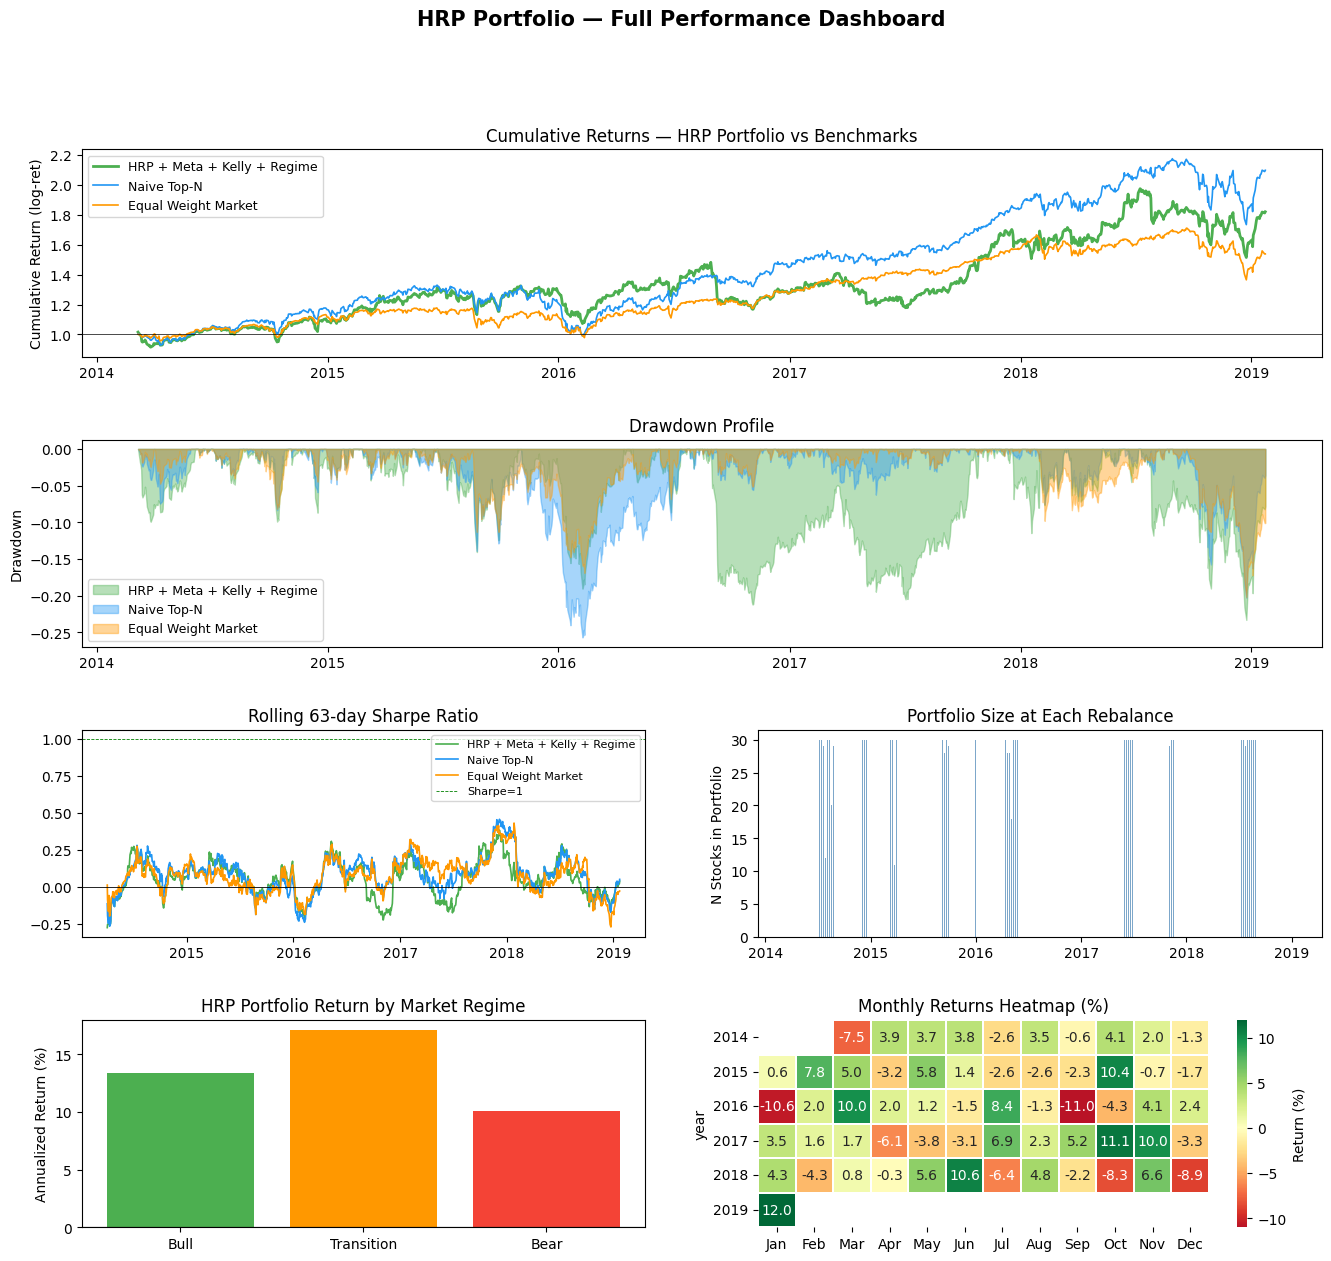

In [10]:
# ── Portfolio Visualization ────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.4)

plot_labels = [
    ('HRP + Meta + Kelly + Regime', portfolio_df['port_ret'], '#4CAF50'),
    ('Naive Top-N',                  naive_ret_df,           '#2196F3'),
    ('Equal Weight Market',          mkt_ew_ret.fillna(0),   '#FF9800'),
]

# 1. Equity curves
ax1 = fig.add_subplot(gs[0, :])
for label, ret_s, color in plot_labels:
    cumret = (1 + ret_s.dropna()).cumprod()
    ax1.plot(cumret.index, cumret.values, label=label, color=color,
             linewidth=2 if label.startswith('HRP') else 1.2)
ax1.axhline(1, color='black', linewidth=0.5)
ax1.set_ylabel('Cumulative Return (log-ret)')
ax1.set_title('Cumulative Returns — HRP Portfolio vs Benchmarks', fontsize=12)
ax1.legend(fontsize=9)

# 2. Drawdown
ax2 = fig.add_subplot(gs[1, :])
for label, ret_s, color in plot_labels:
    cumret = (1 + ret_s.dropna()).cumprod()
    dd = cumret / cumret.cummax() - 1
    ax2.fill_between(dd.index, dd.values, 0, alpha=0.4, color=color, label=label)
ax2.set_ylabel('Drawdown')
ax2.set_title('Drawdown Profile')
ax2.legend(fontsize=9, loc='lower left')

# 3. Rolling Sharpe (63-day)
ax3 = fig.add_subplot(gs[2, 0])
for label, ret_s, color in plot_labels:
    roll_sharpe = (
        ret_s.dropna().rolling(63, min_periods=20).mean() *
        np.sqrt(252) /
        (ret_s.dropna().rolling(63, min_periods=20).std() * np.sqrt(252) + 1e-9)
    )
    ax3.plot(roll_sharpe.index, roll_sharpe.values, label=label, color=color, linewidth=1.2)
ax3.axhline(0, color='black', linewidth=0.6)
ax3.axhline(1, color='green', linewidth=0.6, linestyle='--', label='Sharpe=1')
ax3.set_title('Rolling 63-day Sharpe Ratio')
ax3.legend(fontsize=8)

# 4. HRP weights heatmap over time
ax4 = fig.add_subplot(gs[2, 1])
n_stocks_over_time = [w['n_stocks'] for w in weights_log]
rebal_ts = [w['date'] for w in weights_log]
ax4.bar(rebal_ts, n_stocks_over_time, color='steelblue', alpha=0.7)
ax4.set_ylabel('N Stocks in Portfolio')
ax4.set_title('Portfolio Size at Each Rebalance')

# 5. Regime-conditional returns
if len(weights_log) > 0:
    regime_col = signals[['date', 'regime']].drop_duplicates()
    hrp_with_regime = portfolio_df.reset_index().merge(regime_col, on='date', how='left')
    ax5 = fig.add_subplot(gs[3, 0])
    regime_names = {0: 'Bull', 1: 'Transition', 2: 'Bear'}
    regime_colors_plot = {'Bull': '#4CAF50', 'Transition': '#FF9800', 'Bear': '#f44336'}
    for r, name in regime_names.items():
        sub = hrp_with_regime[hrp_with_regime['regime'] == r]['port_ret']
        ann = sub.mean() * 252 * 100
        ax5.bar(name, ann, color=regime_colors_plot[name])
    ax5.axhline(0, color='black', linewidth=0.8)
    ax5.set_ylabel('Annualized Return (%)')
    ax5.set_title('HRP Portfolio Return by Market Regime')

# 6. Monthly returns heatmap
ax6 = fig.add_subplot(gs[3, 1])
monthly_ret = portfolio_df['port_ret'].resample('M').apply(lambda x: (1+x).prod()-1) * 100
monthly_df  = pd.DataFrame({'year': monthly_ret.index.year, 'month': monthly_ret.index.month, 'ret': monthly_ret.values})
monthly_piv = monthly_df.pivot(index='year', columns='month', values='ret')
monthly_piv.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sns.heatmap(monthly_piv, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            linewidths=0.3, ax=ax6, cbar_kws={'label': 'Return (%)'})
ax6.set_title('Monthly Returns Heatmap (%)')

plt.suptitle('HRP Portfolio — Full Performance Dashboard', fontsize=15, fontweight='bold')
plt.savefig(WD / 'hrp_portfolio_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — Save Portfolio Results

In [11]:
# Daily returns
portfolio_df.to_parquet(WD / 'hrp_portfolio_returns.parquet')

# Benchmark returns
bench_df = pd.DataFrame({
    'hrp_portfolio':   portfolio_df['port_ret'],
    'naive_topn':      naive_ret_df,
    'equal_weight_mkt': mkt_ew_ret
}).reindex(portfolio_df.index)
bench_df.to_parquet(WD / 'benchmark_returns.parquet')

# Weights log
import json
clean_weights_log = []
for w in weights_log:
    entry = {k: v for k, v in w.items() if k != 'weights'}
    entry['top_holdings'] = sorted(
        w['weights'].items(), key=lambda x: -x[1]
    )[:10]  # top 10 holdings
    clean_weights_log.append(entry)
pd.DataFrame(clean_weights_log).to_csv(WD / 'weights_log.csv', index=False)

# Performance comparison CSV
comparison_df.to_csv(WD / 'portfolio_performance_comparison.csv')

print('✓ Saved:')
print('  hrp_portfolio_returns.parquet')
print('  benchmark_returns.parquet')
print('  weights_log.csv')
print('  portfolio_performance_comparison.csv')

print('\n── Final HRP Portfolio Metrics ──')
m = compute_performance_metrics(portfolio_df['port_ret'], 'HRP Portfolio')
for k, v in m.items():
    if k != 'Strategy':
        print(f'  {k:<25}: {v}')

✓ Saved:
  hrp_portfolio_returns.parquet
  benchmark_returns.parquet
  weights_log.csv
  portfolio_performance_comparison.csv

── Final HRP Portfolio Metrics ──
  Annual Return            : 14.44%
  Annual Vol               : 20.74%
  Sharpe                   : 0.697
  Sortino                  : 0.938
  Max Drawdown             : -23.30%
  Calmar                   : 0.620
  Win Rate                 : 54.0%
  Profit Factor            : 1.130
  VaR 95%                  : -2.109%
  CVaR 95%                 : -3.142%
  Total Return             : 82.08%
  N Days                   : 1229
